In [27]:
#initial import of relevant packages for graphing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#https://stackoverflow.com/questions/32085531/importing-a-csv-file-into-python-to-make-scatterplots-and-histograms

In [28]:
#initial read and print of motifs_dataframe
motifs_df = pd.read_csv("../rosetta_motifs/rmsd_total_best_10000.csv")
motifs_df

,system,rmsd,placement_pdb
0,aa2ar,3.759347,aa2ar_ResPos_159_ResID_PHE_Trio33_+_motif_3QO7...
1,abl1,0.086350,abl1_ResPos_83_ResID_THR_Trio24_+_motif_7CD9_F...
2,ace,0.368597,ace_ResPos_293_ResID_SER_Trio17_+_motif_7Q26_8...
3,aces,0.111413,aces_ResPos_359_ResID_HIS_Trio68_+_motif_7AIS_...
4,ada17,0.939694,ada17_ResPos_123_ResID_THR_Trio46_+_motif_3IEB...
...,...,...,...
86,thrb,0.202464,thrb_ResPos_111_ResID_LEU_Trio52_+_motif_6AUE_...
87,tryb1,0.349357,tryb1_ResPos_87_ResID_GLN_Trio5_+_motif_7VHY_6...
88,tysy,0.450841,tysy_ResPos_79_ResID_ILE_Trio48_+_motif_2ZF4_P...
89,urok,0.214195,urok_ResPos_178_ResID_ASP_Trio58_+_motif_6EO6_...


In [29]:
#initial read and print of AutoDock Vina dataframe
ad_df = pd.read_csv("../AutoDock_Vina/ADV_best_rmsds.csv",header=None)
ad_df

,0,1
0,def,2.772277
1,nram,0.533947
2,fa10,0.398882
3,fak1,0.442263
4,aofb,1.491052
...,...,...
97,aldr,0.526612
98,inha,1.883266
99,pur2,0.755583
100,pgh2,0.636627


In [30]:
#rename autodock columns to be "system" and "rmsd" like with motifs dataframe (initial .csv did not have header line)
ad_df.columns = ['system', 'rmsd']
#test print
ad_df

,system,rmsd
0,def,2.772277
1,nram,0.533947
2,fa10,0.398882
3,fak1,0.442263
4,aofb,1.491052
...,...,...
97,aldr,0.526612
98,inha,1.883266
99,pur2,0.755583
100,pgh2,0.636627


In [31]:
#Inner join of motifs and autodock dataframes for plotting purposes; followed with test print
merged_df = pd.merge(motifs_df, ad_df, on='system', how='inner')
merged_df

,system,rmsd_x,placement_pdb,rmsd_y
0,aa2ar,3.759347,aa2ar_ResPos_159_ResID_PHE_Trio33_+_motif_3QO7...,2.403411
1,abl1,0.086350,abl1_ResPos_83_ResID_THR_Trio24_+_motif_7CD9_F...,0.220222
2,ace,0.368597,ace_ResPos_293_ResID_SER_Trio17_+_motif_7Q26_8...,1.308332
3,aces,0.111413,aces_ResPos_359_ResID_HIS_Trio68_+_motif_7AIS_...,0.458188
4,ada17,0.939694,ada17_ResPos_123_ResID_THR_Trio46_+_motif_3IEB...,0.848309
...,...,...,...,...
86,thrb,0.202464,thrb_ResPos_111_ResID_LEU_Trio52_+_motif_6AUE_...,0.281836
87,tryb1,0.349357,tryb1_ResPos_87_ResID_GLN_Trio5_+_motif_7VHY_6...,0.513567
88,tysy,0.450841,tysy_ResPos_79_ResID_ILE_Trio48_+_motif_2ZF4_P...,1.448866
89,urok,0.214195,urok_ResPos_178_ResID_ASP_Trio58_+_motif_6EO6_...,0.757082


In [32]:
#drop placement_pdb column from motifs dataframe
merged_df = merged_df.drop(columns=['placement_pdb'])
#rename columns for rmsd from motifs and autodock
merged_df.columns = ['system', 'rmsd_motifs', 'rmsd_adv']
#test_print
merged_df

,system,rmsd_motifs,rmsd_adv
0,aa2ar,3.759347,2.403411
1,abl1,0.086350,0.220222
2,ace,0.368597,1.308332
3,aces,0.111413,0.458188
4,ada17,0.939694,0.848309
...,...,...,...
86,thrb,0.202464,0.281836
87,tryb1,0.349357,0.513567
88,tysy,0.450841,1.448866
89,urok,0.214195,0.757082


In [33]:
#initial read and print of Schrodinger Glide dataframe
sg_df = pd.read_csv("../schrodinger_glide/glide_best_rmsd.csv")
sg_df

,system_name,best_rmsd,best_rmsd_pose,total_poses
0,aa2ar,7.927534,13.0,15.0
1,abl1,0.424373,1.0,1.0
2,ace,3.781334,1.0,8.0
3,aces,0.638513,4.0,5.0
4,ada,1.452599,1.0,4.0
...,...,...,...,...
97,tysy,1.925273,4.0,4.0
98,urok,0.849532,1.0,5.0
99,vgfr2,1.357784,2.0,3.0
100,wee1,0.710819,6.0,6.0


In [34]:
#rename schrodinger columns to be 'system', 'rmsd', 'best_pose', 'num_poses' like with motifs dataframe (initial .csv did not have header line)
sg_df.columns = ['system', 'rmsd', 'best_pose', 'num_poses']
#test print
sg_df

,system,rmsd,best_pose,num_poses
0,aa2ar,7.927534,13.0,15.0
1,abl1,0.424373,1.0,1.0
2,ace,3.781334,1.0,8.0
3,aces,0.638513,4.0,5.0
4,ada,1.452599,1.0,4.0
...,...,...,...,...
97,tysy,1.925273,4.0,4.0
98,urok,0.849532,1.0,5.0
99,vgfr2,1.357784,2.0,3.0
100,wee1,0.710819,6.0,6.0


In [35]:
sg_df = sg_df[sg_df['rmsd'].isna() == False]
sg_df

,system,rmsd,best_pose,num_poses
0,aa2ar,7.927534,13.0,15.0
1,abl1,0.424373,1.0,1.0
2,ace,3.781334,1.0,8.0
3,aces,0.638513,4.0,5.0
4,ada,1.452599,1.0,4.0
...,...,...,...,...
97,tysy,1.925273,4.0,4.0
98,urok,0.849532,1.0,5.0
99,vgfr2,1.357784,2.0,3.0
100,wee1,0.710819,6.0,6.0


In [36]:
#Inner join of motifs and shrodinger dataframes for plotting purposes; followed with test print
merged_df = pd.merge(merged_df, sg_df, on='system', how='inner')
merged_df

,system,rmsd_motifs,rmsd_adv,rmsd,best_pose,num_poses
0,aa2ar,3.759347,2.403411,7.927534,13.0,15.0
1,abl1,0.086350,0.220222,0.424373,1.0,1.0
2,ace,0.368597,1.308332,3.781334,1.0,8.0
3,aces,0.111413,0.458188,0.638513,4.0,5.0
4,ada17,0.939694,0.848309,2.894450,1.0,9.0
...,...,...,...,...,...,...
85,thrb,0.202464,0.281836,0.320517,1.0,1.0
86,tryb1,0.349357,0.513567,0.933948,1.0,3.0
87,tysy,0.450841,1.448866,1.925273,4.0,4.0
88,urok,0.214195,0.757082,0.849532,1.0,5.0


In [37]:
#drop non-needed columns from merged dataframe
#merged_df = merged_df.drop(columns=['placement_pdb'])
merged_df = merged_df.drop(columns=['best_pose'])
merged_df = merged_df.drop(columns=['num_poses'])
#rename columns for rmsd from motifs and autodock
merged_df.columns = ['system', 'rmsd_motifs', 'rmsd_adv', 'rmsd_sg']
#test_print
merged_df

,system,rmsd_motifs,rmsd_adv,rmsd_sg
0,aa2ar,3.759347,2.403411,7.927534
1,abl1,0.086350,0.220222,0.424373
2,ace,0.368597,1.308332,3.781334
3,aces,0.111413,0.458188,0.638513
4,ada17,0.939694,0.848309,2.894450
...,...,...,...,...
85,thrb,0.202464,0.281836,0.320517
86,tryb1,0.349357,0.513567,0.933948
87,tysy,0.450841,1.448866,1.925273
88,urok,0.214195,0.757082,0.849532


In [38]:
#read in the Dock 3.7 data
dock_df = pd.read_csv("../dock6/dock6_best_rmsds.csv")
dock_df

,system,rmsd
0,def,1.091496
1,nram,5.959094
2,fa10,0.180092
3,fak1,0.278123
4,aofb,0.417968
...,...,...
97,aldr,0.527157
98,inha,1.124074
99,pur2,0.610745
100,pgh2,0.233567


In [39]:
#remove any nan
dock_df = dock_df[dock_df['rmsd'].isna() == False]
dock_df

,system,rmsd
0,def,1.091496
1,nram,5.959094
2,fa10,0.180092
3,fak1,0.278123
4,aofb,0.417968
...,...,...
97,aldr,0.527157
98,inha,1.124074
99,pur2,0.610745
100,pgh2,0.233567


In [40]:
#Inner join of motifs and dock dataframes for plotting purposes; followed with test print
merged_df = pd.merge(merged_df, dock_df, on='system', how='inner')
merged_df

,system,rmsd_motifs,rmsd_adv,rmsd_sg,rmsd
0,aa2ar,3.759347,2.403411,7.927534,0.602898
1,abl1,0.086350,0.220222,0.424373,0.202259
2,ace,0.368597,1.308332,3.781334,0.875376
3,aces,0.111413,0.458188,0.638513,0.136633
4,ada17,0.939694,0.848309,2.894450,0.509063
...,...,...,...,...,...
85,thrb,0.202464,0.281836,0.320517,0.254926
86,tryb1,0.349357,0.513567,0.933948,0.228896
87,tysy,0.450841,1.448866,1.925273,1.454266
88,urok,0.214195,0.757082,0.849532,0.271452


In [41]:
#rename column for rmsd from dock
merged_df.columns = ['system', 'rmsd_motifs', 'rmsd_adv', 'rmsd_sg', 'rmsd_dock']
merged_df

,system,rmsd_motifs,rmsd_adv,rmsd_sg,rmsd_dock
0,aa2ar,3.759347,2.403411,7.927534,0.602898
1,abl1,0.086350,0.220222,0.424373,0.202259
2,ace,0.368597,1.308332,3.781334,0.875376
3,aces,0.111413,0.458188,0.638513,0.136633
4,ada17,0.939694,0.848309,2.894450,0.509063
...,...,...,...,...,...
85,thrb,0.202464,0.281836,0.320517,0.254926
86,tryb1,0.349357,0.513567,0.933948,0.228896
87,tysy,0.450841,1.448866,1.925273,1.454266
88,urok,0.214195,0.757082,0.849532,0.271452


In [42]:
#export the dataframe to a csv file
merged_df.to_csv("systems_merged.csv", index=False)

In [43]:
#read in the Alphafold3 data
af_df = pd.read_csv("../scripts/alphafold3/best_placements_all_cleaned.csv")
af_df

,system,rmsd
0,aa2ar,0.357577
1,abl1,0.094155
2,ace,0.255403
3,aces,0.120352
4,ada,0.310981
...,...,...
85,tysy,0.843161
86,urok,0.212069
87,vgfr2,0.186697
88,wee1,0.235387


In [44]:
#remove any nan
af_df = af_df[af_df['rmsd'].isna() == False]
af_df

,system,rmsd
0,aa2ar,0.357577
1,abl1,0.094155
2,ace,0.255403
3,aces,0.120352
4,ada,0.310981
...,...,...
85,tysy,0.843161
86,urok,0.212069
87,vgfr2,0.186697
88,wee1,0.235387


In [45]:
#Inner join of motifs and dock dataframes for plotting purposes; followed with test print
#merged_df = pd.merge(merged_df, af_df, on='system', how='inner')
#merged_df

In [46]:
#rename column for rmsd from dock
#merged_df.columns = ['system', 'rmsd_motifs', 'rmsd_adv', 'rmsd_sg', 'rmsd_dock', 'rmsd_alphafold']
#merged_df

In [47]:
#bin the placements
# Define the bins
bins = [0, 2, 5, 100000]
labels = ['0-2 Å', '2-5 Å', '>5 Å']

In [48]:
# Function to categorize and count occurrences
def categorize_and_count(column):
    
    if column == 'system': return
    
    return pd.cut(merged_df[column], bins=bins, labels=labels, right=False).value_counts().sort_index()

In [49]:
# Apply the function to each column
categorized_counts = pd.DataFrame({col: categorize_and_count(col) for col in merged_df.columns})
print("\nCategorized Counts DataFrame:")
print(categorized_counts)


Categorized Counts DataFrame:
      system  rmsd_motifs  rmsd_adv  rmsd_sg  rmsd_dock
0-2 Å   None           85        69       58         70
2-5 Å   None            3        14       13          7
>5 Å    None            2         7       19         13


In [24]:
#rename columns
#categorized_counts.columns = ['system','Rosetta Motifs', 'AutoDock Vina', 'Schrodinger Glide', 'Dock 3.7', 'Alphafold3']
categorized_counts.columns = ['system','Rosetta Motifs', 'AutoDock Vina', 'Schrodinger Glide', 'Dock 3.7']

In [25]:
#drop the system column from catagorized_counts:
categorized_counts = categorized_counts.drop(columns=['system'])

t_categorized_counts = categorized_counts.T
t_categorized_counts

,0-2 Å,2-5 Å,>5 Å
Rosetta Motifs,84,3,3
AutoDock Vina,69,14,7
Schrodinger Glide,58,13,19
Dock 3.7,70,7,13


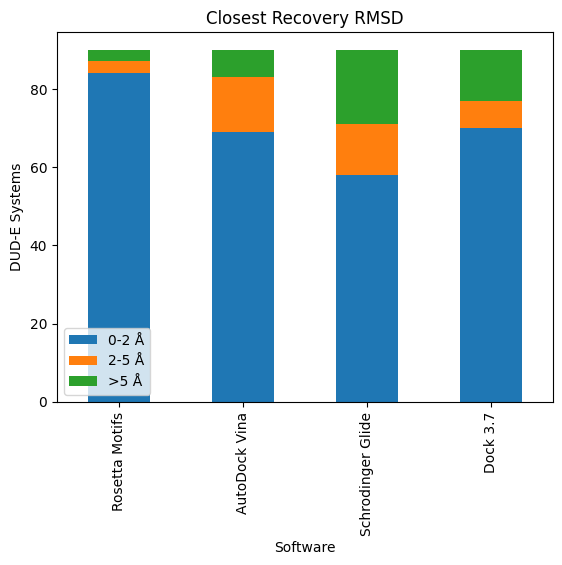

In [26]:
# Plot the data
ax = t_categorized_counts.plot(kind='bar', stacked=True)

# Add labels and title
ax.set_xlabel('Software')
ax.set_ylabel('DUD-E Systems')
ax.set_title('Closest Recovery RMSD')

plt.show()